In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize']=8,3
sns.set_theme(style="whitegrid", palette="dark")

In [2]:
product=pd.read_csv(r'C:\Users\admin\Downloads\archive\indian_pharmaceutical_products_clean.csv')

In [3]:
product

,product_id,brand_name,manufacturer,price_inr,is_discontinued,dosage_form,pack_size,pack_unit,num_active_ingredients,primary_ingredient,primary_strength,active_ingredients,therapeutic_class,packaging_raw,manufacturer_raw
0,1,Augmentin 625 Duo Tablet,Glaxo SmithKline Pharmaceuticals Ltd,223.42,False,tablet,10.0,strip,2,Amoxycillin,500mg,"[{'name': 'Amoxycillin', 'strength': '500mg', ...",antibiotic,strip of 10 tablets,Glaxo SmithKline Pharmaceuticals Ltd
1,2,Azithral 500 Tablet,Alembic Pharmaceuticals Ltd,132.36,False,tablet,5.0,strip,1,Azithromycin,500mg,"[{'name': 'Azithromycin', 'strength': '500mg',...",antibiotic,strip of 5 tablets,Alembic Pharmaceuticals Ltd
2,3,Ascoril LS Syrup,Glenmark Pharmaceuticals Ltd,118.00,False,syrup,100.0,bottle,2,Ambroxol,30mg/5ml,"[{'name': 'Ambroxol', 'strength': '30mg/5ml', ...",bronchodilator,bottle of 100 ml Syrup,Glenmark Pharmaceuticals Ltd
3,4,Allegra 120mg Tablet,Sanofi India Ltd,218.81,False,tablet,10.0,strip,1,Fexofenadine,120mg,"[{'name': 'Fexofenadine', 'strength': '120mg',...",antihistamine,strip of 10 tablets,Sanofi India Ltd
4,5,Avil 25 Tablet,Sanofi India Ltd,10.96,False,tablet,15.0,strip,1,Pheniramine,25mg,"[{'name': 'Pheniramine', 'strength': '25mg', '...",other,strip of 15 tablets,Sanofi India Ltd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253968,253969,Ziyapod 100mg Oral Suspension,Ziyana Lifesciences Pvt Ltd,62.30,False,suspension,30.0,bottle,1,Cefpodoxime Proxetil,100mg,"[{'name': 'Cefpodoxime Proxetil', 'strength': ...",other,bottle of 30 ml Oral Suspension,Ziyana Lifesciences Pvt Ltd
253969,253970,Zemhart 30mg Tablet,Leeford Healthcare Ltd,54.00,False,tablet,10.0,strip,1,Diltiazem,30mg,"[{'name': 'Diltiazem', 'strength': '30mg', 'fu...",other,strip of 10 tablets,Leeford Healthcare Ltd
253970,253971,Zivex 25mg Tablet,Euro Organics,57.00,False,tablet,10.0,strip,1,Hydroxyzine,25mg,"[{'name': 'Hydroxyzine', 'strength': '25mg', '...",other,strip of 10 tablets,Euro Organics
253971,253972,ZI Fast 500mg Injection,Burgeon Health Series Private Limited,152.00,False,injection,NaN,NaN,1,Azithromycin,500mg,"[{'name': 'Azithromycin', 'strength': '500mg',...",antibiotic,vial of 1 Injection,Burgeon Health Series Private Limited


In [4]:
product.shape

(253973, 15)

In [5]:
product.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253973 entries, 0 to 253972
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   product_id              253973 non-null  int64  
 1   brand_name              253973 non-null  object 
 2   manufacturer            253973 non-null  object 
 3   price_inr               253973 non-null  float64
 4   is_discontinued         253973 non-null  bool   
 5   dosage_form             253973 non-null  object 
 6   pack_size               231643 non-null  float64
 7   pack_unit               231643 non-null  object 
 8   num_active_ingredients  253973 non-null  int64  
 9   primary_ingredient      253973 non-null  object 
 10  primary_strength        228775 non-null  object 
 11  active_ingredients      253973 non-null  object 
 12  therapeutic_class       253973 non-null  object 
 13  packaging_raw           253973 non-null  object 
 14  manufacturer_raw    

In [6]:
product.isnull().sum()

product_id                    0
brand_name                    0
manufacturer                  0
price_inr                     0
is_discontinued               0
dosage_form                   0
pack_size                 22330
pack_unit                 22330
num_active_ingredients        0
primary_ingredient            0
primary_strength          25198
active_ingredients            0
therapeutic_class             0
packaging_raw                 0
manufacturer_raw              0
dtype: int64

In [7]:
for col in product.columns:
    if product[col].dtype == 'float64' or product[col].dtype == 'int64':
        product[col] = product[col].fillna(0)
    elif product[col].dtype == 'object':
        product[col] = product[col].fillna('Unknown')
print(product.isnull().sum())


product_id                0
brand_name                0
manufacturer              0
price_inr                 0
is_discontinued           0
dosage_form               0
pack_size                 0
pack_unit                 0
num_active_ingredients    0
primary_ingredient        0
primary_strength          0
active_ingredients        0
therapeutic_class         0
packaging_raw             0
manufacturer_raw          0
dtype: int64


In [8]:
product.columns

Index(['product_id', 'brand_name', 'manufacturer', 'price_inr',
       'is_discontinued', 'dosage_form', 'pack_size', 'pack_unit',
       'num_active_ingredients', 'primary_ingredient', 'primary_strength',
       'active_ingredients', 'therapeutic_class', 'packaging_raw',
       'manufacturer_raw'],
      dtype='object')

In [9]:
len(product.columns)

15

In [10]:
product.dtypes

product_id                  int64
brand_name                 object
manufacturer               object
price_inr                 float64
is_discontinued              bool
dosage_form                object
pack_size                 float64
pack_unit                  object
num_active_ingredients      int64
primary_ingredient         object
primary_strength           object
active_ingredients         object
therapeutic_class          object
packaging_raw              object
manufacturer_raw           object
dtype: object

In [11]:
product.describe()

,product_id,price_inr,pack_size,num_active_ingredients
count,253973.000000,253973.000000,253973.000000,253973.000000
mean,126987.000000,270.530844,17.319317,1.441893
std,73315.834296,3029.584134,35.475945,0.496795
min,1.000000,0.000000,0.000000,1.000000
25%,63494.000000,48.000000,10.000000,1.000000
50%,126987.000000,79.000000,10.000000,1.000000
75%,190480.000000,140.000000,10.000000,2.000000
max,253973.000000,436000.000000,5000.000000,5.000000


In [12]:
product.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
product_id,253973.0,126987.000000,73315.834296,1.0,63494.0,126987.0,190480.0,253973.0
price_inr,253973.0,270.530844,3029.584134,0.0,48.0,79.0,140.0,436000.0
pack_size,253973.0,17.319317,35.475945,0.0,10.0,10.0,10.0,5000.0
num_active_ingredients,253973.0,1.441893,0.496795,1.0,1.0,1.0,2.0,5.0


In [13]:
product.tail()

,product_id,brand_name,manufacturer,price_inr,is_discontinued,dosage_form,pack_size,pack_unit,num_active_ingredients,primary_ingredient,primary_strength,active_ingredients,therapeutic_class,packaging_raw,manufacturer_raw
253968,253969,Ziyapod 100mg Oral Suspension,Ziyana Lifesciences Pvt Ltd,62.3,False,suspension,30.0,bottle,1,Cefpodoxime Proxetil,100mg,"[{'name': 'Cefpodoxime Proxetil', 'strength': ...",other,bottle of 30 ml Oral Suspension,Ziyana Lifesciences Pvt Ltd
253969,253970,Zemhart 30mg Tablet,Leeford Healthcare Ltd,54.0,False,tablet,10.0,strip,1,Diltiazem,30mg,"[{'name': 'Diltiazem', 'strength': '30mg', 'fu...",other,strip of 10 tablets,Leeford Healthcare Ltd
253970,253971,Zivex 25mg Tablet,Euro Organics,57.0,False,tablet,10.0,strip,1,Hydroxyzine,25mg,"[{'name': 'Hydroxyzine', 'strength': '25mg', '...",other,strip of 10 tablets,Euro Organics
253971,253972,ZI Fast 500mg Injection,Burgeon Health Series Private Limited,152.0,False,injection,0.0,Unknown,1,Azithromycin,500mg,"[{'name': 'Azithromycin', 'strength': '500mg',...",antibiotic,vial of 1 Injection,Burgeon Health Series Private Limited
253972,253973,Zyvocol 1% Dusting Powder,GBK Healthcare,110.0,False,powder,75.0,gm,1,Clotrimazole,Unknown,"[{'name': 'Clotrimazole', 'strength': None, 'f...",other,bottle of 75 gm Dusting Powder,GBK Healthcare


In [14]:
product.head()

,product_id,brand_name,manufacturer,price_inr,is_discontinued,dosage_form,pack_size,pack_unit,num_active_ingredients,primary_ingredient,primary_strength,active_ingredients,therapeutic_class,packaging_raw,manufacturer_raw
0,1,Augmentin 625 Duo Tablet,Glaxo SmithKline Pharmaceuticals Ltd,223.42,False,tablet,10.0,strip,2,Amoxycillin,500mg,"[{'name': 'Amoxycillin', 'strength': '500mg', ...",antibiotic,strip of 10 tablets,Glaxo SmithKline Pharmaceuticals Ltd
1,2,Azithral 500 Tablet,Alembic Pharmaceuticals Ltd,132.36,False,tablet,5.0,strip,1,Azithromycin,500mg,"[{'name': 'Azithromycin', 'strength': '500mg',...",antibiotic,strip of 5 tablets,Alembic Pharmaceuticals Ltd
2,3,Ascoril LS Syrup,Glenmark Pharmaceuticals Ltd,118.00,False,syrup,100.0,bottle,2,Ambroxol,30mg/5ml,"[{'name': 'Ambroxol', 'strength': '30mg/5ml', ...",bronchodilator,bottle of 100 ml Syrup,Glenmark Pharmaceuticals Ltd
3,4,Allegra 120mg Tablet,Sanofi India Ltd,218.81,False,tablet,10.0,strip,1,Fexofenadine,120mg,"[{'name': 'Fexofenadine', 'strength': '120mg',...",antihistamine,strip of 10 tablets,Sanofi India Ltd
4,5,Avil 25 Tablet,Sanofi India Ltd,10.96,False,tablet,15.0,strip,1,Pheniramine,25mg,"[{'name': 'Pheniramine', 'strength': '25mg', '...",other,strip of 15 tablets,Sanofi India Ltd


<Axes: xlabel='price_inr', ylabel='Density'>

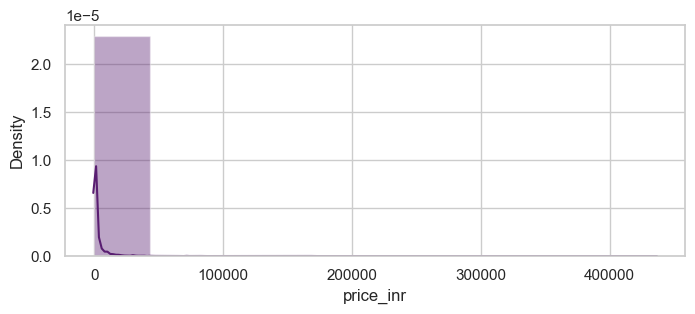

In [15]:
sns.distplot(product.price_inr,color='m',bins=10)

<Axes: xlabel='pack_size', ylabel='Density'>

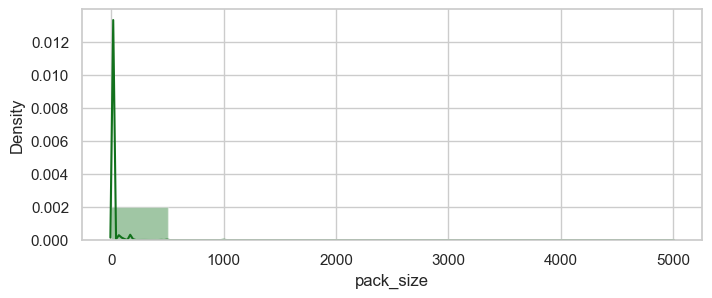

In [16]:
sns.distplot(product.pack_size,color='g',bins=10)

<Axes: xlabel='num_active_ingredients', ylabel='Density'>

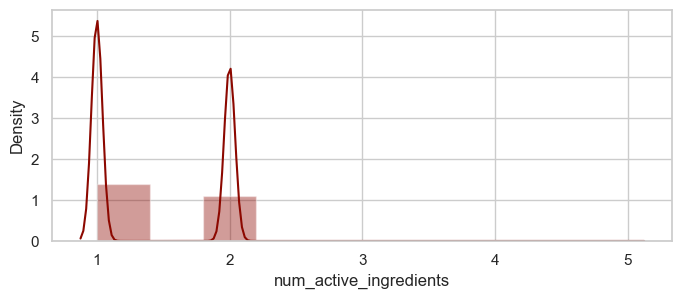

In [17]:
sns.distplot(product.num_active_ingredients,color='r',bins=10)

In [18]:
product.head()

,product_id,brand_name,manufacturer,price_inr,is_discontinued,dosage_form,pack_size,pack_unit,num_active_ingredients,primary_ingredient,primary_strength,active_ingredients,therapeutic_class,packaging_raw,manufacturer_raw
0,1,Augmentin 625 Duo Tablet,Glaxo SmithKline Pharmaceuticals Ltd,223.42,False,tablet,10.0,strip,2,Amoxycillin,500mg,"[{'name': 'Amoxycillin', 'strength': '500mg', ...",antibiotic,strip of 10 tablets,Glaxo SmithKline Pharmaceuticals Ltd
1,2,Azithral 500 Tablet,Alembic Pharmaceuticals Ltd,132.36,False,tablet,5.0,strip,1,Azithromycin,500mg,"[{'name': 'Azithromycin', 'strength': '500mg',...",antibiotic,strip of 5 tablets,Alembic Pharmaceuticals Ltd
2,3,Ascoril LS Syrup,Glenmark Pharmaceuticals Ltd,118.00,False,syrup,100.0,bottle,2,Ambroxol,30mg/5ml,"[{'name': 'Ambroxol', 'strength': '30mg/5ml', ...",bronchodilator,bottle of 100 ml Syrup,Glenmark Pharmaceuticals Ltd
3,4,Allegra 120mg Tablet,Sanofi India Ltd,218.81,False,tablet,10.0,strip,1,Fexofenadine,120mg,"[{'name': 'Fexofenadine', 'strength': '120mg',...",antihistamine,strip of 10 tablets,Sanofi India Ltd
4,5,Avil 25 Tablet,Sanofi India Ltd,10.96,False,tablet,15.0,strip,1,Pheniramine,25mg,"[{'name': 'Pheniramine', 'strength': '25mg', '...",other,strip of 15 tablets,Sanofi India Ltd


<Axes: xlabel='is_discontinued', ylabel='count'>

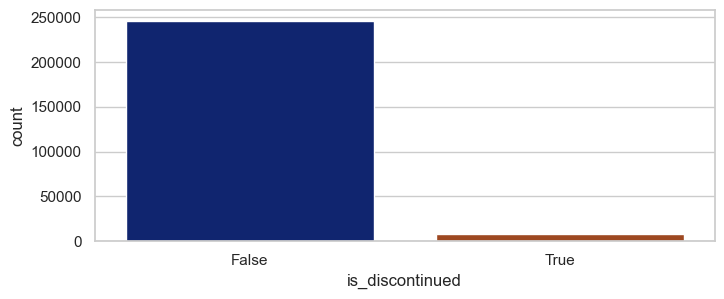

In [19]:
sns.countplot(data=product,x='is_discontinued',palette='dark')

<Axes: xlabel='dosage_form', ylabel='count'>

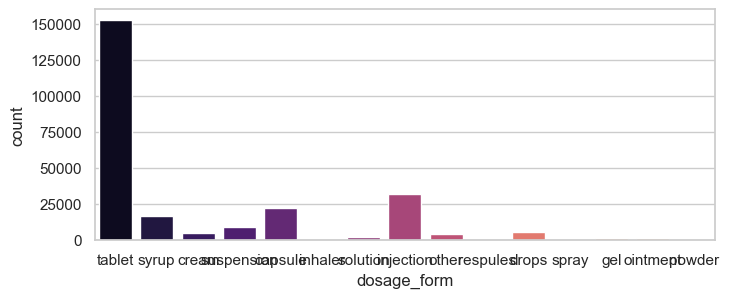

In [20]:
sns.countplot(data=product,x='dosage_form',palette='magma')

<Axes: xlabel='pack_unit', ylabel='count'>

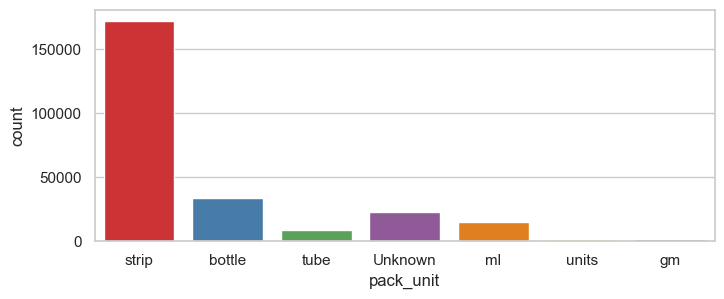

In [21]:
sns.countplot(data=product,x='pack_unit',palette='Set1')

<Axes: xlabel='therapeutic_class', ylabel='count'>

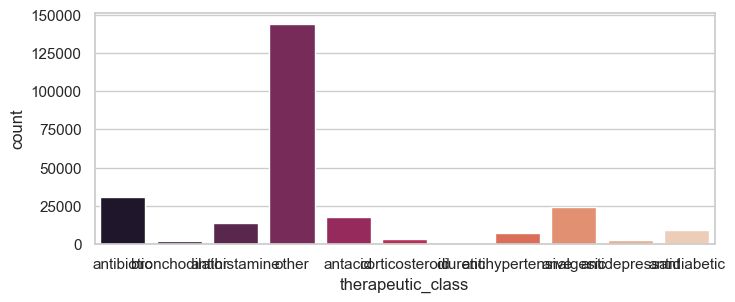

In [22]:
sns.countplot(data=product,x='therapeutic_class',palette='rocket')

<Axes: xlabel='pack_unit', ylabel='count'>

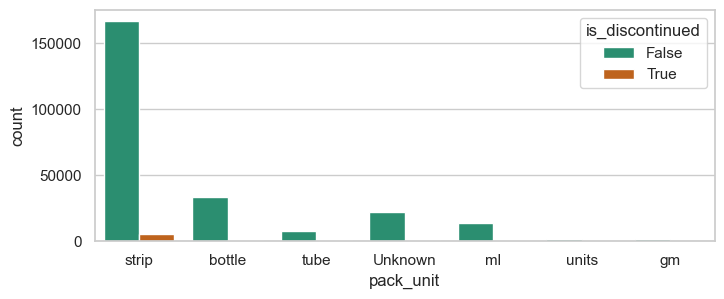

In [23]:
sns.countplot(data=product,x='pack_unit',hue='is_discontinued',palette='Dark2')

In [24]:
product.head(1)

,product_id,brand_name,manufacturer,price_inr,is_discontinued,dosage_form,pack_size,pack_unit,num_active_ingredients,primary_ingredient,primary_strength,active_ingredients,therapeutic_class,packaging_raw,manufacturer_raw
0,1,Augmentin 625 Duo Tablet,Glaxo SmithKline Pharmaceuticals Ltd,223.42,False,tablet,10.0,strip,2,Amoxycillin,500mg,"[{'name': 'Amoxycillin', 'strength': '500mg', ...",antibiotic,strip of 10 tablets,Glaxo SmithKline Pharmaceuticals Ltd


<Axes: xlabel='pack_unit', ylabel='price_inr'>

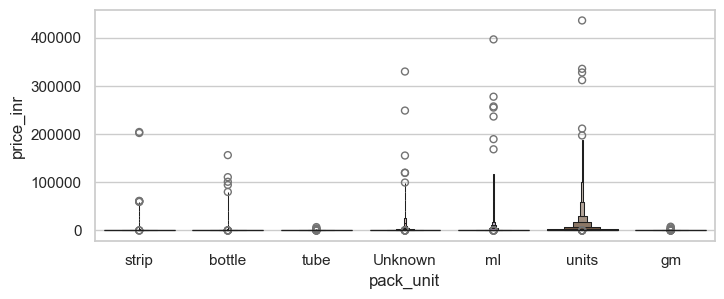

In [25]:
sns.boxenplot(data=product,x='pack_unit',y='price_inr',palette='dark')

<Axes: xlabel='is_discontinued', ylabel='pack_size'>

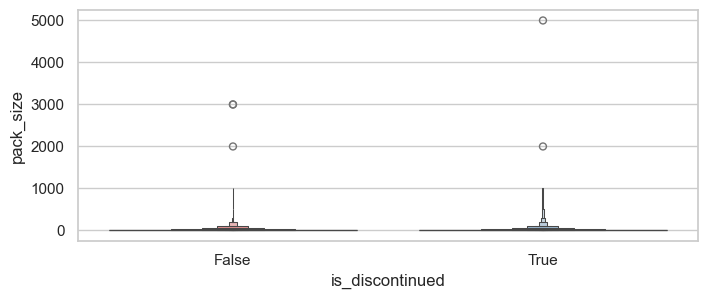

In [26]:
sns.boxenplot(data=product,x='is_discontinued',y='pack_size',palette='Set1')

<Axes: xlabel='pack_unit', ylabel='num_active_ingredients'>

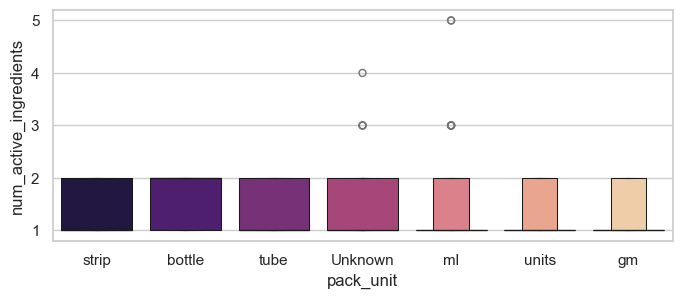

In [27]:
sns.boxenplot(data=product,x='pack_unit',y='num_active_ingredients',palette='magma')

<Axes: xlabel='is_discontinued', ylabel='price_inr'>

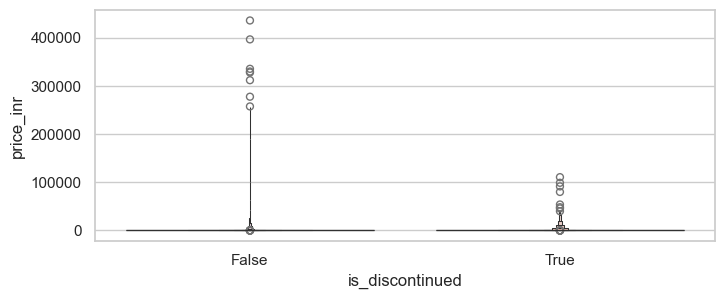

In [28]:
sns.boxenplot(data=product,x='is_discontinued',y='price_inr',palette='rocket')

<Axes: xlabel='is_discontinued', ylabel='num_active_ingredients'>

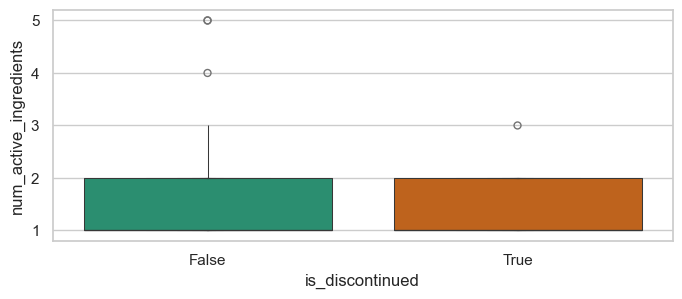

In [29]:
sns.boxenplot(data=product,x='is_discontinued',y='num_active_ingredients',palette='Dark2')

In [30]:
product.head(1)

,product_id,brand_name,manufacturer,price_inr,is_discontinued,dosage_form,pack_size,pack_unit,num_active_ingredients,primary_ingredient,primary_strength,active_ingredients,therapeutic_class,packaging_raw,manufacturer_raw
0,1,Augmentin 625 Duo Tablet,Glaxo SmithKline Pharmaceuticals Ltd,223.42,False,tablet,10.0,strip,2,Amoxycillin,500mg,"[{'name': 'Amoxycillin', 'strength': '500mg', ...",antibiotic,strip of 10 tablets,Glaxo SmithKline Pharmaceuticals Ltd


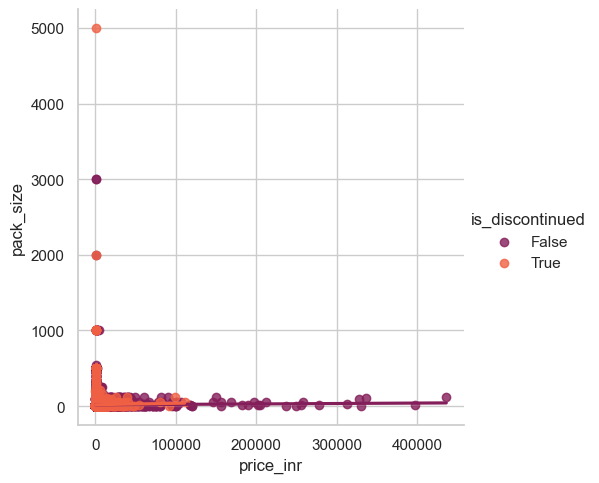

In [31]:
sns.lmplot(data=product,x='price_inr',y='pack_size',palette='rocket',hue='is_discontinued')

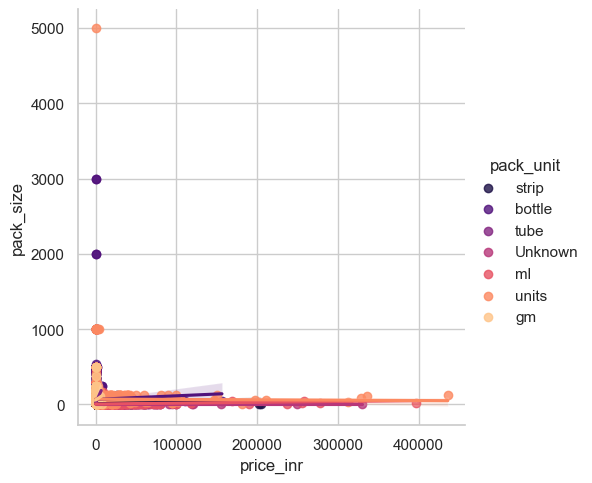

In [32]:
sns.lmplot(data=product,x='price_inr',y='pack_size',palette='magma',hue='pack_unit')

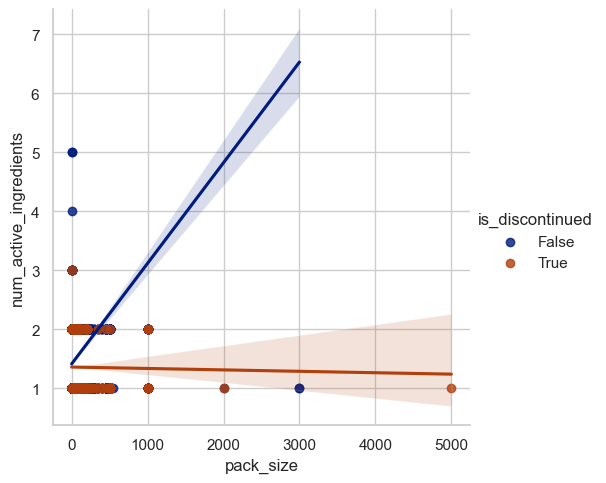

In [33]:
sns.lmplot(data=product,x='pack_size',y='num_active_ingredients',palette='dark',hue='is_discontinued')

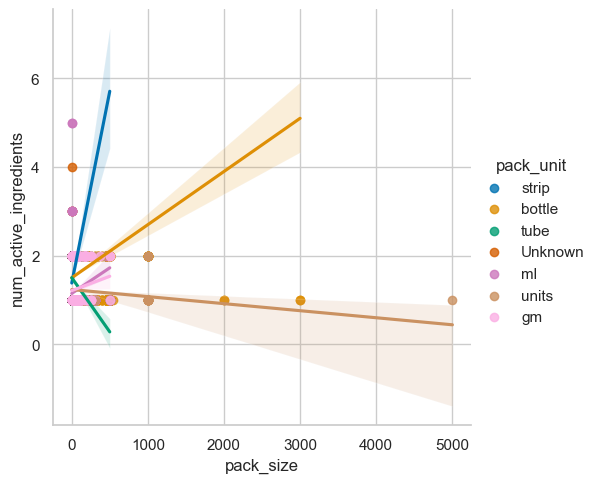

In [34]:
sns.lmplot(data=product,x='pack_size',y='num_active_ingredients',palette='colorblind',hue='pack_unit')

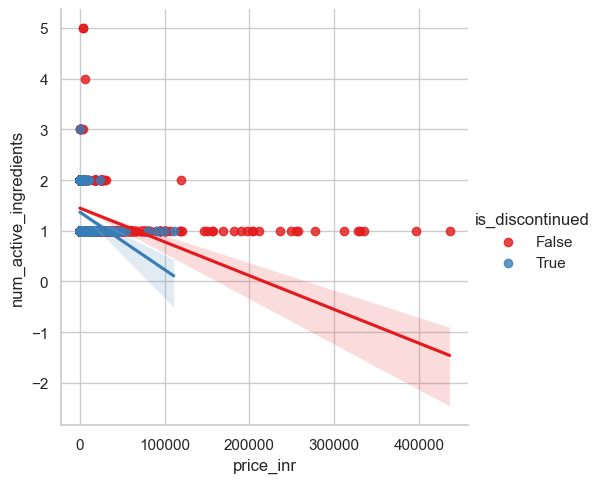

In [35]:
sns.lmplot(data=product,x='price_inr',y='num_active_ingredients',palette='Set1',hue='is_discontinued')

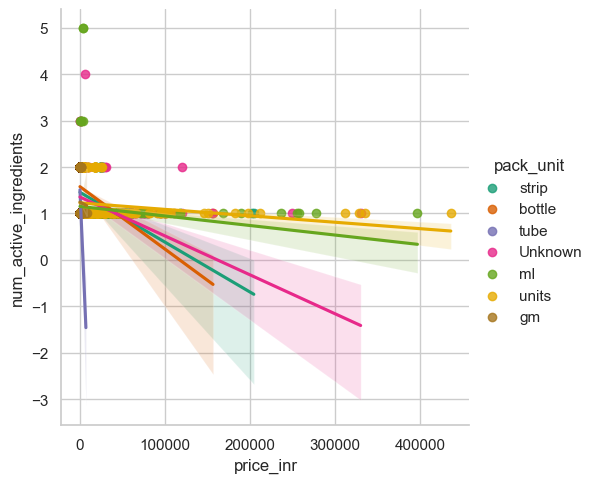

In [36]:
sns.lmplot(data=product,x='price_inr',y='num_active_ingredients',palette='Dark2',hue='pack_unit')

In [37]:
product.head(1)

,product_id,brand_name,manufacturer,price_inr,is_discontinued,dosage_form,pack_size,pack_unit,num_active_ingredients,primary_ingredient,primary_strength,active_ingredients,therapeutic_class,packaging_raw,manufacturer_raw
0,1,Augmentin 625 Duo Tablet,Glaxo SmithKline Pharmaceuticals Ltd,223.42,False,tablet,10.0,strip,2,Amoxycillin,500mg,"[{'name': 'Amoxycillin', 'strength': '500mg', ...",antibiotic,strip of 10 tablets,Glaxo SmithKline Pharmaceuticals Ltd


<Axes: xlabel='pack_unit', ylabel='price_inr'>

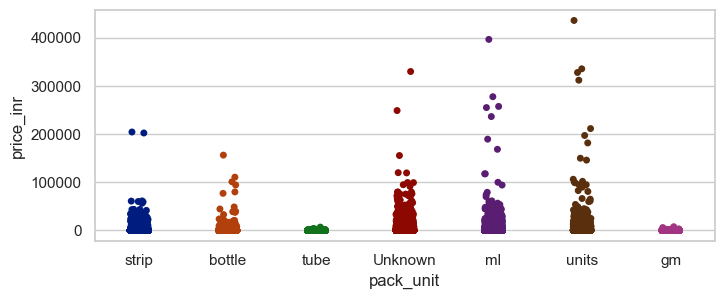

In [38]:
sns.stripplot(data=product,x='pack_unit',y='price_inr',palette='dark')

<Axes: xlabel='is_discontinued', ylabel='pack_size'>

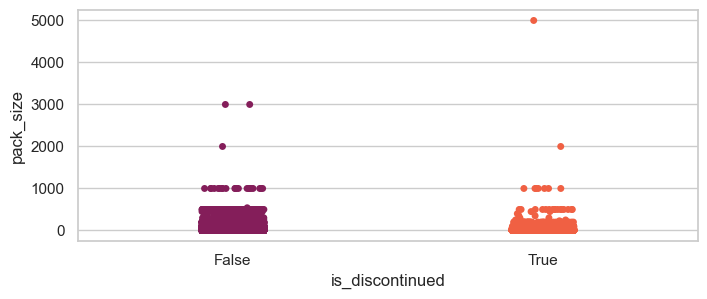

In [39]:
sns.stripplot(data=product,x='is_discontinued',y='pack_size',palette='rocket')

<Axes: xlabel='pack_unit', ylabel='num_active_ingredients'>

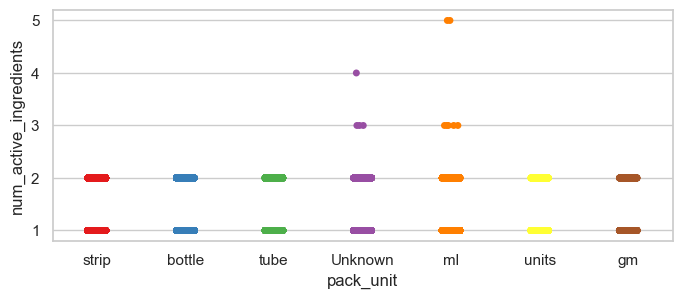

In [40]:
sns.stripplot(data=product,x='pack_unit',y='num_active_ingredients',palette='Set1')

In [41]:
product.head(1)

,product_id,brand_name,manufacturer,price_inr,is_discontinued,dosage_form,pack_size,pack_unit,num_active_ingredients,primary_ingredient,primary_strength,active_ingredients,therapeutic_class,packaging_raw,manufacturer_raw
0,1,Augmentin 625 Duo Tablet,Glaxo SmithKline Pharmaceuticals Ltd,223.42,False,tablet,10.0,strip,2,Amoxycillin,500mg,"[{'name': 'Amoxycillin', 'strength': '500mg', ...",antibiotic,strip of 10 tablets,Glaxo SmithKline Pharmaceuticals Ltd


<Axes: xlabel='price_inr', ylabel='Density'>

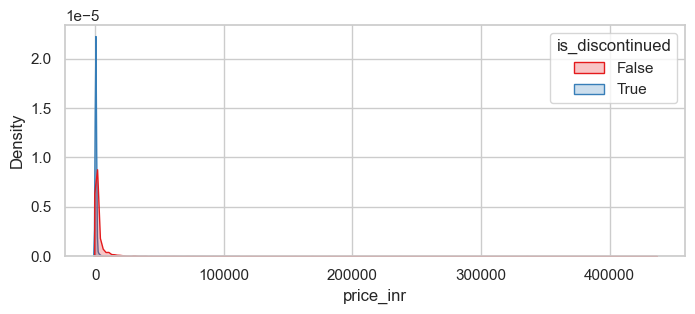

In [42]:
sns.kdeplot(data=product ,x='price_inr',hue='is_discontinued',palette='Set1',fill=True)

<Axes: xlabel='pack_size', ylabel='Density'>

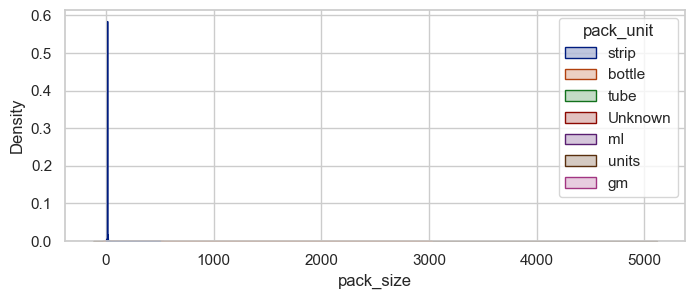

In [43]:
sns.kdeplot(data=product ,x='pack_size',hue='pack_unit',palette='dark',fill=True)

<Axes: xlabel='num_active_ingredients', ylabel='Density'>

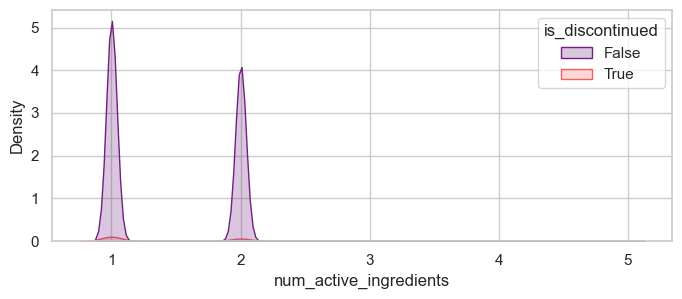

In [44]:
sns.kdeplot(data=product ,x='num_active_ingredients',hue='is_discontinued',palette='magma',fill=True)

<Axes: xlabel='pack_size', ylabel='Density'>

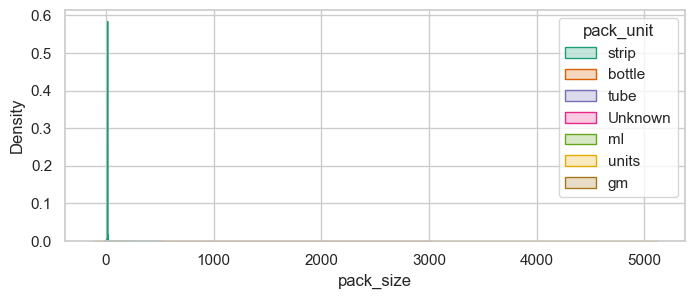

In [45]:
sns.kdeplot(data=product ,x='pack_size',hue='pack_unit',palette='Dark2',fill=True)

In [46]:
product.head(1)

,product_id,brand_name,manufacturer,price_inr,is_discontinued,dosage_form,pack_size,pack_unit,num_active_ingredients,primary_ingredient,primary_strength,active_ingredients,therapeutic_class,packaging_raw,manufacturer_raw
0,1,Augmentin 625 Duo Tablet,Glaxo SmithKline Pharmaceuticals Ltd,223.42,False,tablet,10.0,strip,2,Amoxycillin,500mg,"[{'name': 'Amoxycillin', 'strength': '500mg', ...",antibiotic,strip of 10 tablets,Glaxo SmithKline Pharmaceuticals Ltd


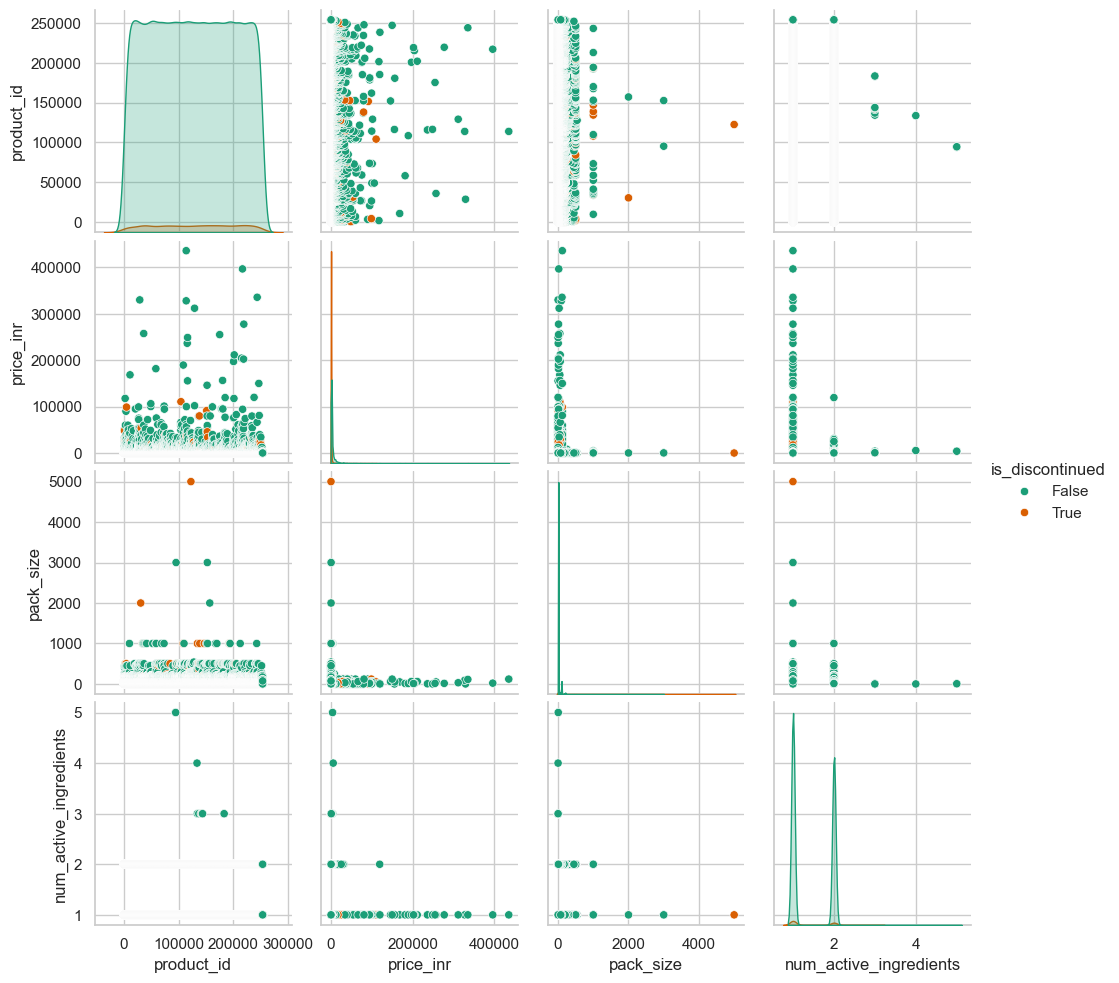

In [47]:
sns.pairplot(product, hue="is_discontinued",palette='Dark2')

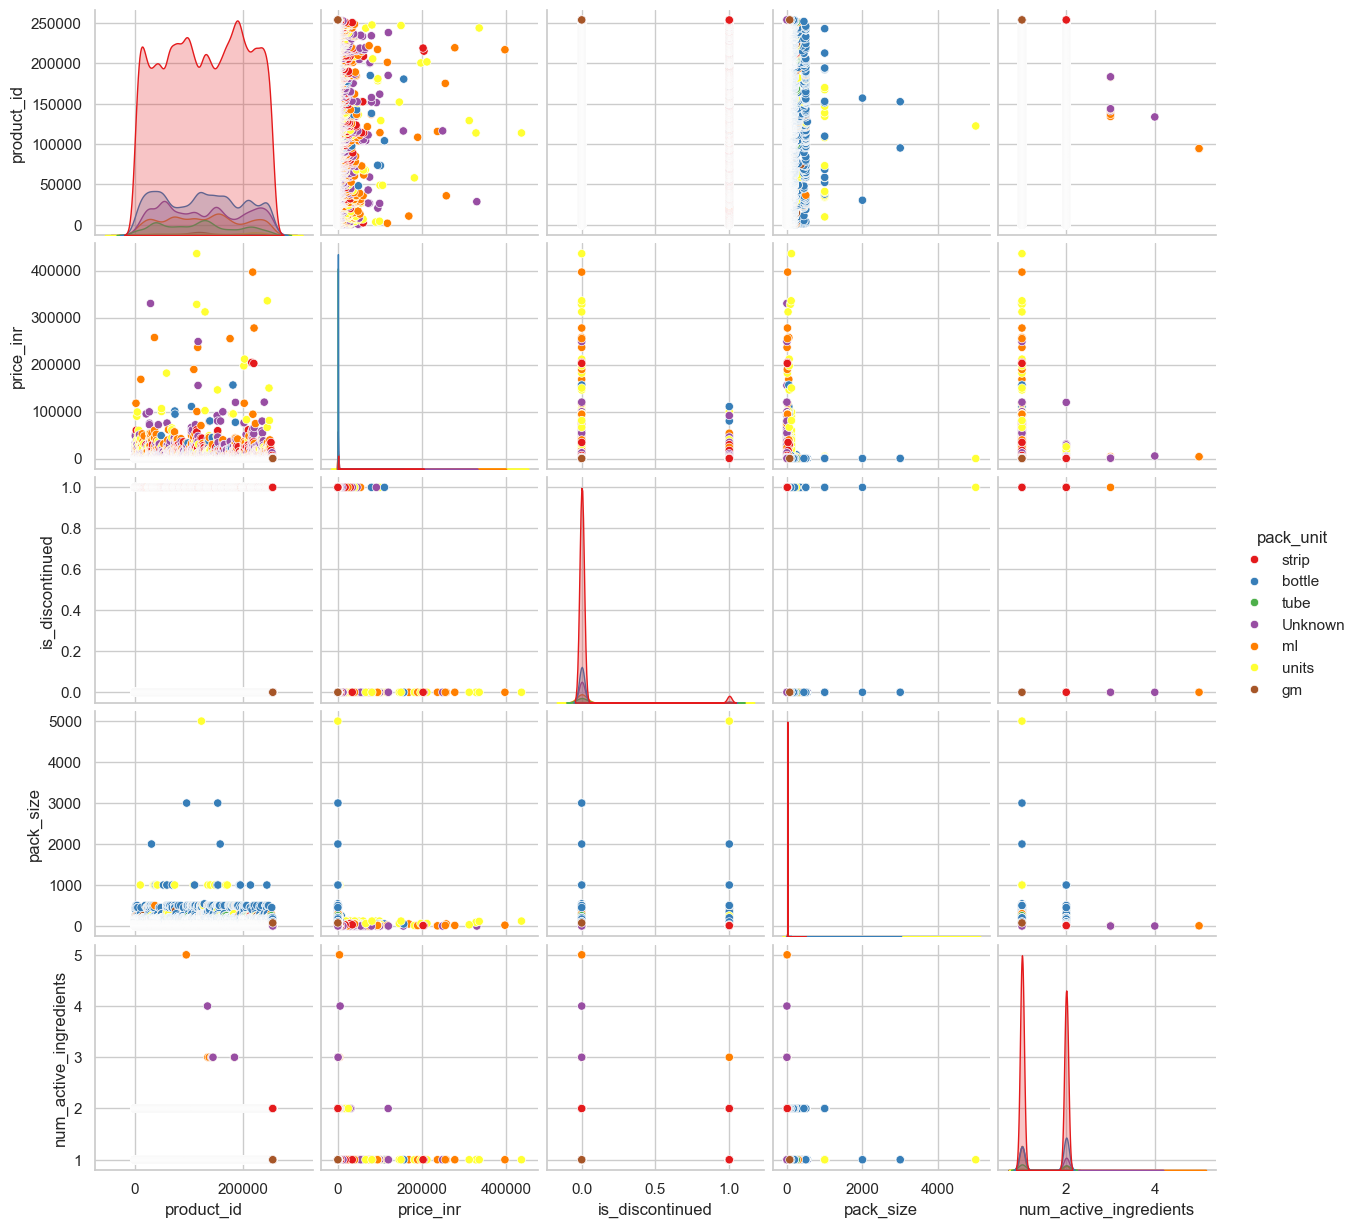

In [48]:
sns.pairplot(product, hue="pack_unit",palette='Set1')